<a href="https://colab.research.google.com/github/CSrory/genai-bootcamp-lab1/blob/main/W3S2_Lab_Image_Generation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<div style="background:linear-gradient(135deg,#16304A 0%,#003C9C 100%);border-radius:14px;padding:22px 26px;color:#fff;font-family:Segoe UI,Arial,sans-serif;">
  <div style="display:flex;justify-content:space-between;align-items:center;gap:16px;">
    <div>
      <div style="font-size:13px;letter-spacing:1px;opacity:.85;text-transform:uppercase;">Generative AI Summer Bootcamp &middot; Najran University</div>
      <div style="font-size:26px;font-weight:800;margin-top:4px;">Lab — Text-to-Image with Diffusers</div>
      <div style="font-size:15px;opacity:.92;margin-top:4px;">Week 3 · Session 2 — Diffusion & Text-to-Image</div>
    </div>
    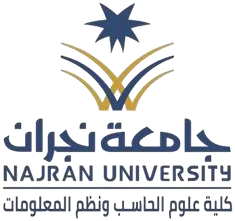
  </div>
  <div style="margin-top:16px;display:flex;gap:10px;flex-wrap:wrap;font-size:13px;">
    <span style="background:rgba(255,255,255,.16);padding:5px 12px;border-radius:20px;">🏆 NCA-GENM track</span>
    <span style="background:rgba(255,255,255,.16);padding:5px 12px;border-radius:20px;">⏱️ Lab: ≈ 45 minutes</span>
    <span style="background:rgba(255,255,255,.16);padding:5px 12px;border-radius:20px;">▶️ Runs on Google Colab (free)</span>
  </div>
</div>

<a target="_blank" href="https://colab.research.google.com/"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<div style="border:1px solid #003C9C33;border-left:6px solid #003C9C;background:#EAF1FB;border-radius:10px;padding:16px 20px;font-family:Segoe UI,Arial,sans-serif;">
<div style="font-weight:800;color:#003C9C;font-size:16px;margin-bottom:6px;">🎓 Learning objectives</div>
<ul style="margin:0;padding-left:20px;font-size:15px;color:#16304A;"><li style="margin:5px 0;">Load a fast <b>diffusion</b> model (SDXL-Turbo) in fp16 on a free T4 GPU.</li>
<li style="margin:5px 0;">Generate images from your own <b>prompts</b> and control the output.</li>
<li style="margin:5px 0;">See how <b>seed</b> and number of <b>steps</b> change the result.</li>
<li style="margin:5px 0;">Reshape an existing image with <b>img2img</b>.</li></ul></div>

## How to use this notebook

Run the cells **in order**, top to bottom (`Shift+Enter`). Read the short notes before each part — they connect the code back to today's slides on diffusion and text-to-image.

<div style="border:1px solid #16304A33;border-left:6px solid #16304A;background:#EDF1F6;border-radius:10px;padding:14px 18px;margin:6px 0;font-family:Segoe UI,Arial,sans-serif;">
<div style="font-weight:800;color:#16304A;font-size:15px;margin-bottom:4px;">🔧 First: turn on the free GPU</div>
<div style="font-size:15px;color:#1B2A3A;line-height:1.5;">Click <b>Runtime → Change runtime type → T4 GPU → Save</b>. Diffusion needs a GPU — on CPU each image can take minutes.</div></div>

### Setup
We install **diffusers** (the image-generation library), plus `transformers` and `accelerate`. All models in this lab are **open and ungated** — no Hugging Face token or login is required. If pip prints any red dependency warnings, you can safely ignore them.

In [1]:
# One-time setup (~30-60 seconds)
import torch
assert torch.cuda.is_available(), "No GPU! Runtime -> Change runtime type -> T4 GPU -> Save, then re-run this cell."
!pip -q install -U "diffusers>=0.39,<1.0" "transformers>=4.44,<6" accelerate

# Keep the lab output clean (hides harmless library deprecation notices)
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)
from diffusers.utils import logging as diffusers_logging
diffusers_logging.set_verbosity_error()

print("Setup complete — GPU:", torch.cuda.get_device_name(0))

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.6/5.6 MB 140.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.5/11.5 MB 131.8 MB/s eta 0:00:00
Setup complete — GPU: Tesla T4


## Part 1 — Load a diffusion model

We use **`stabilityai/sdxl-turbo`** — a *distilled* SDXL that produces a good image in just **1-4 steps**, so it is fast enough for a free T4. We load it in **fp16** (half precision) to fit in VRAM.

In [5]:
import torch
from diffusers import AutoPipelineForText2Image
from diffusers.utils import make_image_grid

MODEL_ID = "stabilityai/sdxl-turbo"   # open & ungated; ~7 GB in fp16, fits the T4

# Safe to re-run: free any previous pipelines first, or VRAM fills up
for _old in ("pipe", "pipe_i2i"):
    if _old in globals():
        del globals()[_old]
torch.cuda.empty_cache()

pipe = AutoPipelineForText2Image.from_pretrained(
    MODEL_ID,
    torch_dtype=torch.float16,   # half precision -> half the memory
    variant="fp16",
)
pipe = pipe.to("cuda")
# (diffusers runs the VAE in fp32 automatically -> no black/NaN images on the T4)
print("Pipeline loaded on:", pipe.device)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_validators.py:205: UserWarning: The `local_dir_use_symlinks` argument is deprecated and ignored in `hf_hub_download`. Downloading to a local directory does not use symlinks anymore.
  warnings.warn(


model_index.json:   0%|          | 0.00/685 [00:00<?, ?B/s]

Fetching 18 files:   0%|          | 0/18 [00:00<?, ?it/s]

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/517 [00:00<?, ?it/s]

Pipeline loaded on: cuda:0


<div style="border:1px solid #003C9C33;border-left:6px solid #003C9C;background:#EAF1FB;border-radius:10px;padding:14px 18px;margin:6px 0;font-family:Segoe UI,Arial,sans-serif;">
<div style="font-weight:800;color:#003C9C;font-size:15px;margin-bottom:4px;">ℹ️ Turbo models: two must-know settings</div>
<div style="font-size:15px;color:#1B2A3A;line-height:1.5;">Turbo (distilled) models were trained <b>without</b> classifier-free guidance, so you must set <b><code style="background:#EEF3F8;padding:1px 5px;border-radius:4px;">guidance_scale=0.0</code></b>, and <b>1-4 steps</b> is enough. This is the speed/quality trade-off from the slides.</div></div>

### Your first image
`512x512` is the native resolution for SDXL-Turbo and gives the best results.

  0%|          | 0/2 [00:00<?, ?it/s]

Done. Resolution: (512, 512)


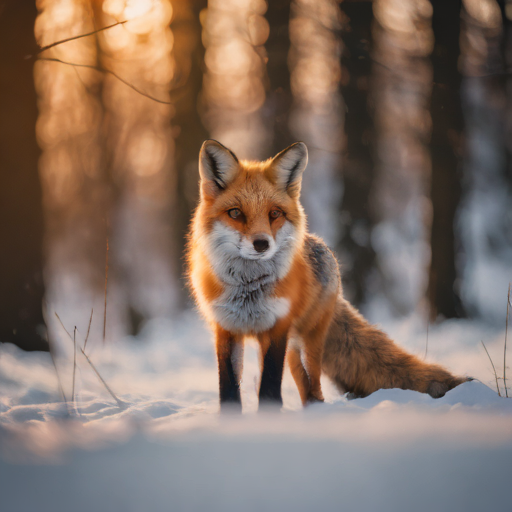

In [13]:
from IPython.display import display

prompt = "A cinematic photo of a red fox in a snowy forest at golden hour, highly detailed"
image = pipe(prompt=prompt, num_inference_steps=2, guidance_scale=0.0).images[0]#قيدنس دايم صفر والستيب كل مانرفعو الدقه تصير احسن
print("Done. Resolution:", image.size)
display(image)

<div style="border:1px solid #C2670D33;border-left:6px solid #C2670D;background:#FCEFE0;border-radius:10px;padding:14px 18px;margin:6px 0;font-family:Segoe UI,Arial,sans-serif;">
<div style="font-weight:800;color:#C2670D;font-size:15px;margin-bottom:4px;">⚠️ If a model fails to load (out of memory / disk)</div>
<div style="font-size:15px;color:#1B2A3A;line-height:1.5;">First try <b>Runtime → Restart session</b>, then re-run from the setup cell. If it still fails, fall back to the smaller <b><code style="background:#EEF3F8;padding:1px 5px;border-radius:4px;">stabilityai/sd-turbo</code></b> (~2.6 GB; same recipe: 512x512, guidance 0.0, 1-4 steps): set <code style="background:#EEF3F8;padding:1px 5px;border-radius:4px;">MODEL_ID = "stabilityai/sd-turbo"</code> and re-run Part 1.</div></div>

## Part 2 — Prompts (and a negative prompt)

A good prompt names the **subject, style, lighting and composition**. A **negative prompt** lists what to avoid. Let's wrap generation in a small helper.

  0%|          | 0/4 [00:00<?, ?it/s]

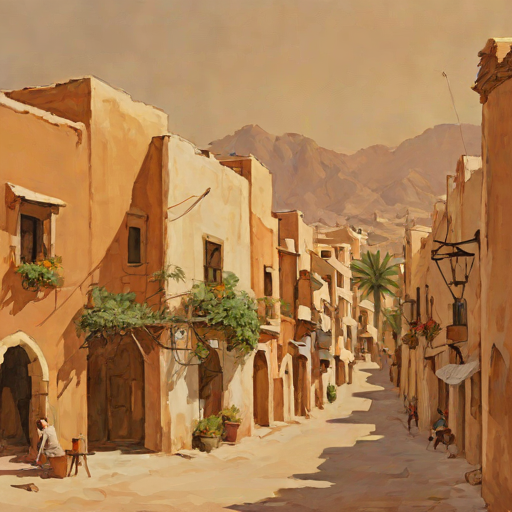

In [14]:
def generate(prompt, negative_prompt=None, steps=2, seed=None):
    """Generate one image with SDXL-Turbo (guidance is fixed at 0.0 for turbo)."""
    generator = None
    if seed is not None:
        generator = torch.Generator(device="cuda").manual_seed(seed)
    return pipe(
        prompt=prompt,
        negative_prompt=negative_prompt,
        num_inference_steps=steps,
        guidance_scale=0.0,
        generator=generator,
    ).images[0]

img = generate(
    "a  oil color painting of the old town of Najran, Saudi Arabia, warm tones",
    negative_prompt="blurry, low quality, distorted, text, watermark",
    steps=4,
)
display(img)

<div style="border:1px solid #003C9C33;border-left:6px solid #003C9C;background:#EAF1FB;border-radius:10px;padding:14px 18px;margin:6px 0;font-family:Segoe UI,Arial,sans-serif;">
<div style="font-weight:800;color:#003C9C;font-size:15px;margin-bottom:4px;">ℹ️ When does the negative prompt actually do something?</div>
<div style="font-size:15px;color:#1B2A3A;line-height:1.5;">A negative prompt only takes effect when <b>guidance_scale > 1</b>. Because Turbo runs at guidance 0, it has little/no effect here — to really use it, switch to a classic model like <code style="background:#EEF3F8;padding:1px 5px;border-radius:4px;">stable-diffusion-v1-5/stable-diffusion-v1-5</code> with <code style="background:#EEF3F8;padding:1px 5px;border-radius:4px;">guidance_scale=7.5</code> and 25-50 steps. We keep it in the helper so the habit carries over.</div></div>

<div style="border:1px solid #0C607833;border-left:6px solid #0C6078;background:#E4F1F0;border-radius:10px;padding:14px 18px;margin:6px 0;font-family:Segoe UI,Arial,sans-serif;">
<div style="font-weight:800;color:#0C6078;font-size:15px;margin-bottom:4px;">🎯 Exam tip — NCA-GENM</div>
<div style="font-size:15px;color:#1B2A3A;line-height:1.5;">Image generation lives in the <b>Multimodal Data</b> domain, and fp16 / steps / memory tricks live in <b>Performance Optimization</b>. Remember: latent diffusion denoises a *compressed* latent, then a <b>VAE</b> decodes it to pixels.</div></div>

## Part 3 — Seed and steps

The **seed** fixes the starting noise. Same seed + same settings = **the same image** every time (reproducibility). More **steps** generally means a cleaner image, but slower.

### Same seed → identical images (the cell generates twice)

  0%|          | 0/2 [00:00<?, ?it/s]

  0%|          | 0/2 [00:00<?, ?it/s]

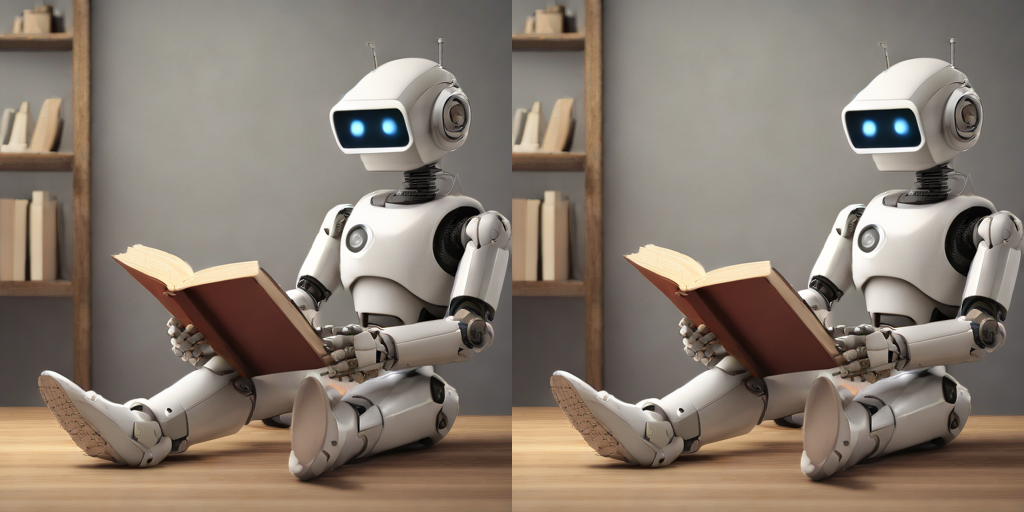

In [16]:
a = generate("a friendly robot reading a book, 3d render, studio lighting", seed=42)
b = generate("a friendly robot reading a book, 3d render, studio lighting", seed=42)
display(make_image_grid([a, b], rows=1, cols=2))   # the two should look identical

### Different seeds → different images

  0%|          | 0/2 [00:00<?, ?it/s]

  0%|          | 0/2 [00:00<?, ?it/s]

  0%|          | 0/2 [00:00<?, ?it/s]

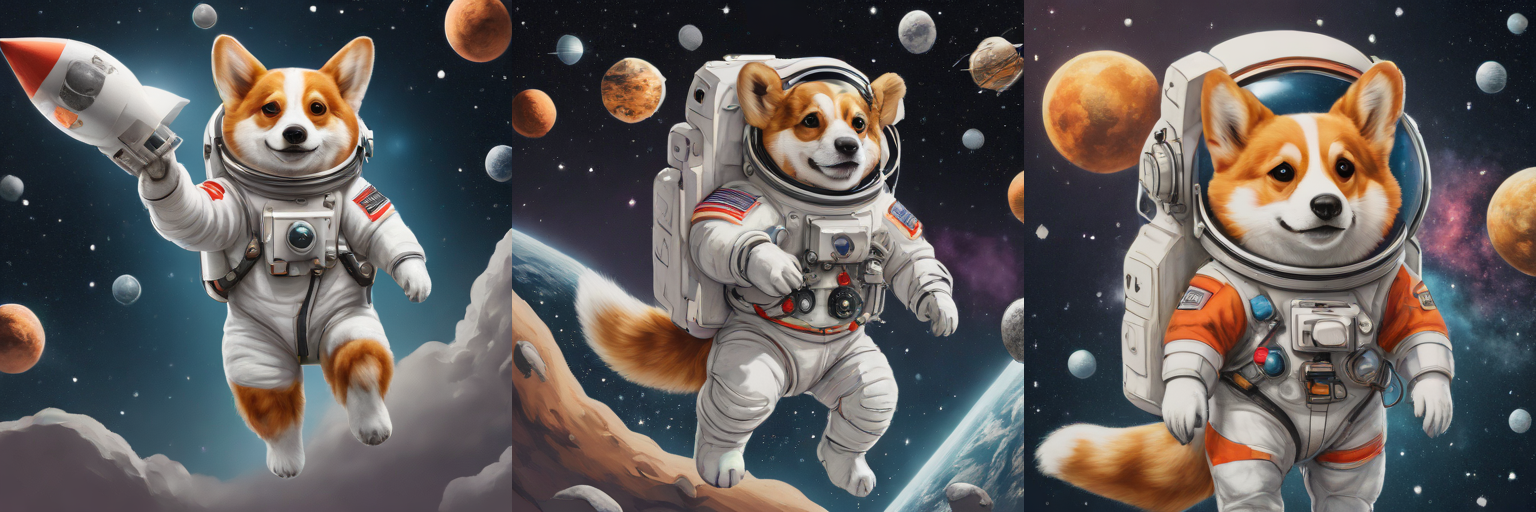

In [19]:
prompt = "a cute corgi astronaut floating in space, digital art"
images = [generate(prompt, seed=s) for s in (0, 1, 5)]
display(make_image_grid(images, rows=1, cols=3))

### More steps → (usually) more detail

  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/2 [00:00<?, ?it/s]

  0%|          | 0/6 [00:00<?, ?it/s]

Left to right: 1, 2, 4 steps


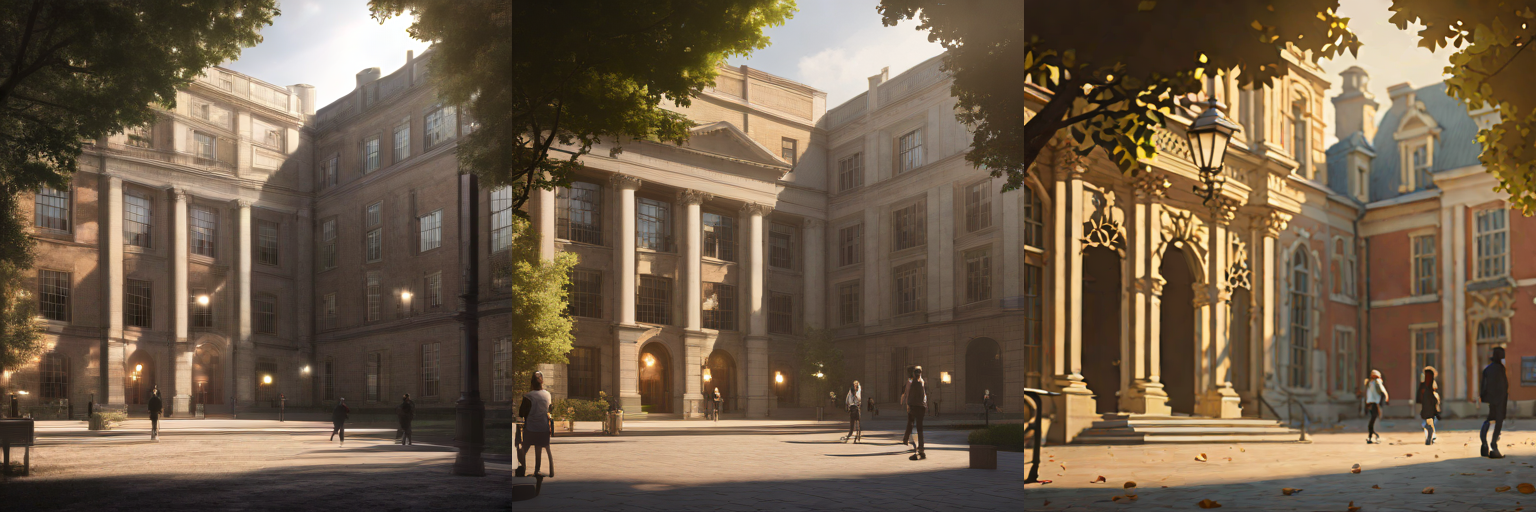

In [18]:
prompt = "a university campus , realistic details,cinematic light"
imgs = [generate(prompt, steps=n, seed=7) for n in (1, 2, 6)]
print("Left to right: 1, 2, 4 steps")
display(make_image_grid(imgs, rows=1, cols=3))

<div style="border:1px solid #6B3FA033;border-left:6px solid #6B3FA0;background:#F1ECF8;border-radius:10px;padding:14px 18px;margin:6px 0;font-family:Segoe UI,Arial,sans-serif;">
<div style="font-weight:800;color:#6B3FA0;font-size:15px;margin-bottom:4px;">✍️ Your turn</div>
<div style="font-size:15px;color:#1B2A3A;line-height:1.5;">Write your <b>own</b> prompt below. Then change the <b>seed</b> to explore variations, and try <b>1 vs 4 steps</b>. Which gives you the best result?</div></div>

  0%|          | 0/2 [00:00<?, ?it/s]

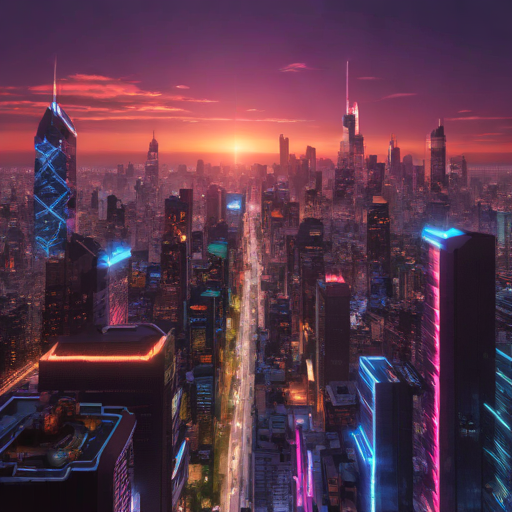

In [24]:
# Edit the prompt, seed and steps, then run
my_prompt = "a futuristic city skyline at sunset, neon lights, ultra detailed"
my_image = generate(my_prompt, steps=2, seed=7)
display(my_image)

## Part 4 — img2img: start from a picture

Instead of starting from pure noise, **img2img** starts from an existing image and reshapes it toward a new prompt. **`strength`** controls how much it changes (0 = keep the original, 1 = redraw from scratch).

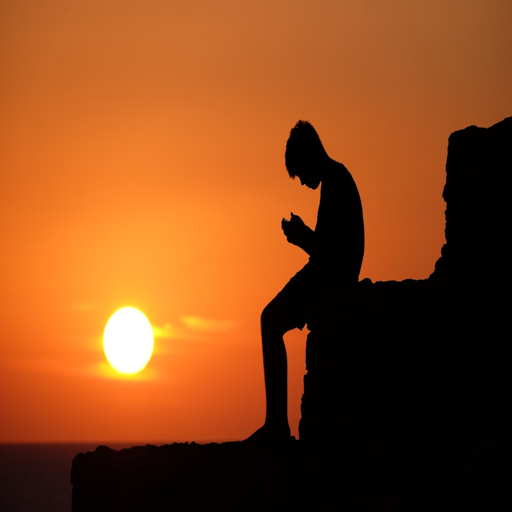

In [6]:
from diffusers import AutoPipelineForImage2Image
from diffusers.utils import load_image

# from_pipe reuses the model we already loaded -> no extra VRAM
pipe_i2i = AutoPipelineForImage2Image.from_pipe(pipe).to("cuda")

url = ("https://images.unsplash.com/photo-1698700777799-85732abc45b4?q=80&w=1170&auto=format&fit=crop&ixlib=rb-4.1.0&ixid=M3wxMjA3fDB8MHxwaG90by1wYWdlfHx8fGVufDB8fHx8fA%3D%3D")
init_image = load_image(url).resize((512, 512))
display(init_image)   # the starting image

<div style="border:1px solid #24783033;border-left:6px solid #247830;background:#E9F5EC;border-radius:10px;padding:14px 18px;margin:6px 0;font-family:Segoe UI,Arial,sans-serif;">
<div style="font-weight:800;color:#247830;font-size:15px;margin-bottom:4px;">💡 Turbo + img2img: keep steps × strength ≥ 1</div>
<div style="font-size:15px;color:#1B2A3A;line-height:1.5;">img2img runs for <code style="background:#EEF3F8;padding:1px 5px;border-radius:4px;">int(num_inference_steps * strength)</code> steps. With Turbo this product must be <b>≥ 1</b>, e.g. <code style="background:#EEF3F8;padding:1px 5px;border-radius:4px;">strength=0.6</code> and <code style="background:#EEF3F8;padding:1px 5px;border-radius:4px;">steps=3</code> → <code style="background:#EEF3F8;padding:1px 5px;border-radius:4px;">int(1.8)=1</code> step. If it drops below 1 you get <b>0 steps and a confusing error</b> — recover by re-running the Part-1 load cell and the img2img setup cell above.</div></div>

  0%|          | 0/2 [00:00<?, ?it/s]

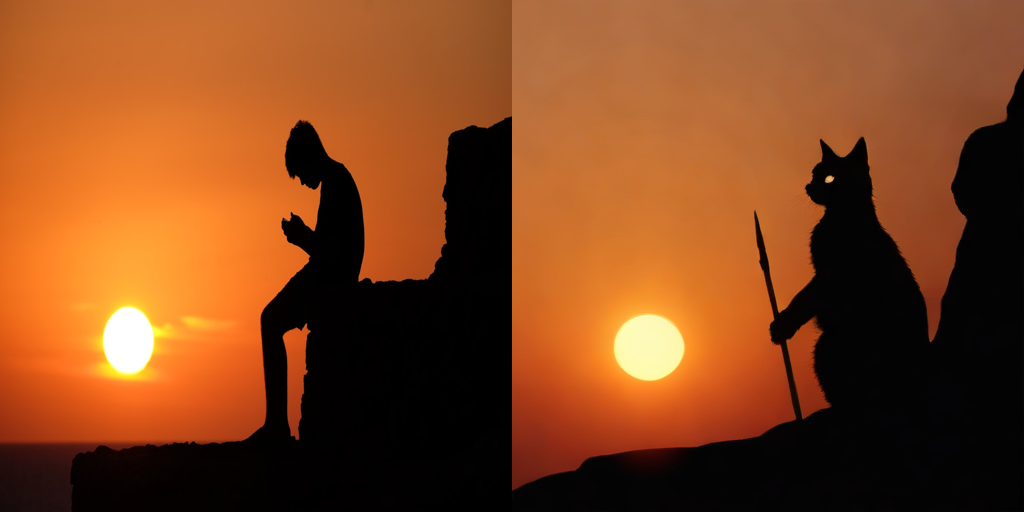

In [7]:
edit_prompt = "a majestic cat wizard, fantasy, glowing magic, highly detailed, 8k"

result = pipe_i2i(
    prompt=edit_prompt,
    image=init_image,
    strength=0.8,           # how far to move from the original
    num_inference_steps=3,  # 0.6 * 3 = 1.8 -> 1 actual step
    guidance_scale=0.0,
).images[0]

display(make_image_grid([init_image, result], rows=1, cols=2))

<div style="border:1px solid #6B3FA033;border-left:6px solid #6B3FA0;background:#F1ECF8;border-radius:10px;padding:14px 18px;margin:6px 0;font-family:Segoe UI,Arial,sans-serif;">
<div style="font-weight:800;color:#6B3FA0;font-size:15px;margin-bottom:4px;">✍️ Your turn</div>
<div style="font-size:15px;color:#1B2A3A;line-height:1.5;">Re-run the img2img cell with a <b>different <code style="background:#EEF3F8;padding:1px 5px;border-radius:4px;">strength</code></b> (try <code style="background:#EEF3F8;padding:1px 5px;border-radius:4px;">0.3</code> — with <code style="background:#EEF3F8;padding:1px 5px;border-radius:4px;">num_inference_steps=4</code> so the product stays ≥ 1 — then <code style="background:#EEF3F8;padding:1px 5px;border-radius:4px;">0.9</code>) and a new <code style="background:#EEF3F8;padding:1px 5px;border-radius:4px;">edit_prompt</code>. Notice how low strength keeps the cat, while high strength reinvents it.</div></div>

  0%|          | 0/3 [00:00<?, ?it/s]

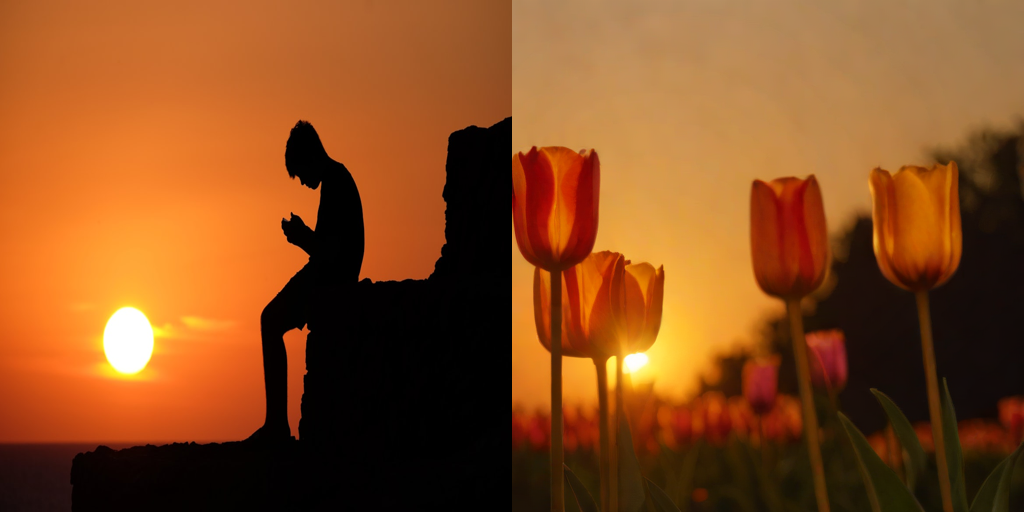

In [11]:
# Try strength 0.3 (subtle) vs 0.9 (dramatic) — remember steps * strength >= 1
out = pipe_i2i(
    prompt="Tulip garden, a far forest",
    image=init_image, strength=0.9, num_inference_steps=4, guidance_scale=0.0,
).images[0]
display(make_image_grid([init_image, out], rows=1, cols=2))

<div style="border:1px solid #24783033;border-left:6px solid #247830;background:#E9F5EC;border-radius:10px;padding:16px 20px;font-family:Segoe UI,Arial,sans-serif;">
<div style="font-weight:800;color:#247830;font-size:16px;margin-bottom:6px;">✅ Recap &amp; exam-readiness check</div>
<ul style="margin:0;padding-left:20px;font-size:15px;"><li style="margin:5px 0;">Diffusion generates by <b>iteratively denoising</b> random noise into an image.</li>
<li style="margin:5px 0;"><b>Latent diffusion</b> denoises a small compressed latent; a <b>VAE</b> decodes it to pixels.</li>
<li style="margin:5px 0;">A <b>CLIP</b> text encoder turns your prompt into conditioning that steers every step.</li>
<li style="margin:5px 0;"><b>Turbo</b> models: <code>guidance_scale=0.0</code> and just <b>1-4 steps</b>.</li>
<li style="margin:5px 0;"><b>Seed</b> makes results reproducible; <b>steps</b> trade speed for quality.</li>
<li style="margin:5px 0;"><b>img2img</b> starts from an image; <code>strength</code> controls how much it changes (keep steps × strength ≥ 1).</li>
<li style="margin:5px 0;"><b>fp16</b> + a distilled Turbo model let a big model run fast on a free T4 — the Performance Optimization idea.</li></ul></div>

---
### Save your work
Commit this notebook to your **`genai-bootcamp-lab1`** GitHub repo from the Week-1 setup lab (`File → Save a copy in GitHub`). Next session: more multimodal — image captioning, VQA and audio.